In [11]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='google.protobuf.symbol_database')

import os
import pickle
import cv2
import numpy as np
import mediapipe as mp
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:

# Mediapipe setup
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles


In [13]:
# Data directory and containers
DATA_DIR = 'dataset'
data = []
labels = []


In [14]:
# Data Processing
def process_data():
    hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.3)
    # Process each item in the dataset directory
    for dir_ in os.listdir(DATA_DIR):
        dir_path = os.path.join(DATA_DIR, dir_)
        if os.path.isdir(dir_path):  # Check if it is a directory
            for img_path in os.listdir(dir_path):
                data_aux = []
                img = cv2.imread(os.path.join(dir_path, img_path))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Flip the image horizontally
                img_flipped = cv2.flip(img_rgb, 1)
                
                for img_variant in [img_rgb, img_flipped]:  # Use original and flipped images
                    data_aux = []
                    results = hands.process(img_variant)
                    if results.multi_hand_landmarks:
                        for hand_landmarks in results.multi_hand_landmarks:
                            for i in range(len(hand_landmarks.landmark)):
                                x = hand_landmarks.landmark[i].x
                                y = hand_landmarks.landmark[i].y
                                data_aux.append(x)
                                data_aux.append(y)
                        # Ensure the feature vector length is consistent
                        if len(data_aux) == 42:  # 21 landmarks * 2 (x, y)
                            data.append(data_aux)
                            labels.append(dir_)



    # Convert labels to numerical format
    label_encoder = LabelEncoder()
    labels_encoded = label_encoder.fit_transform(labels)

    # Save the processed data and label encoder
    with open('data.pickle', 'wb') as f:
        pickle.dump({'data': data, 'labels': labels_encoded}, f)
    with open('label_encoder.pickle', 'wb') as f:
        pickle.dump(label_encoder, f)

In [15]:
def load_data():
    data_dict = pickle.load(open('data.pickle', 'rb'))
    data = np.asarray(data_dict['data'])
    labels = np.asarray(data_dict['labels'])

    # Scale the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    with open('scaler.pickle', 'wb') as f:
        pickle.dump(scaler, f)

    return train_test_split(data_scaled, labels, test_size=0.2, shuffle=True, stratify=labels)


In [16]:
def train_model(x_train, y_train):
    model = SVC(kernel='linear', C=1.0, probability=True)
    model.fit(x_train, y_train)
    
    # Save the trained model
    with open('model.p', 'wb') as f:
        pickle.dump({'model': model}, f)
    
    return model


In [17]:
# Evaluate model
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, x_test, y_test, cv=5, scoring='accuracy')

    print('Mean Squared Error:', mse)
    print('R2 Score:', r2)
    print(f'Accuracy: {accuracy * 100:.2f}%')
    print(f'Cross-Validation Accuracy Scores: {cv_scores}')
    print(f'Mean Cross-Validation Accuracy: {cv_scores.mean()}')

    return y_pred, mse


In [18]:
# Visualize feature importances
def visualize_feature_importances(model):
    importances = np.abs(model.coef_[0])
    importances = importances.reshape((21, 2))

    plt.figure(figsize=(12, 8))
    sns.heatmap(importances, annot=True, cmap='viridis', xticklabels=['x', 'y'], yticklabels=[f'landmark_{i}' for i in range(21)])
    plt.title('Feature Importances Heatmap')
    plt.xlabel('Coordinate')
    plt.ylabel('Landmark')
    plt.show()

Mean Squared Error: 0.18095238095238095
R2 Score: 0.9736932327654412
Accuracy: 96.19%
Cross-Validation Accuracy Scores: [0.71428571 0.71428571 0.71428571 0.80952381 0.85714286]
Mean Cross-Validation Accuracy: 0.761904761904762


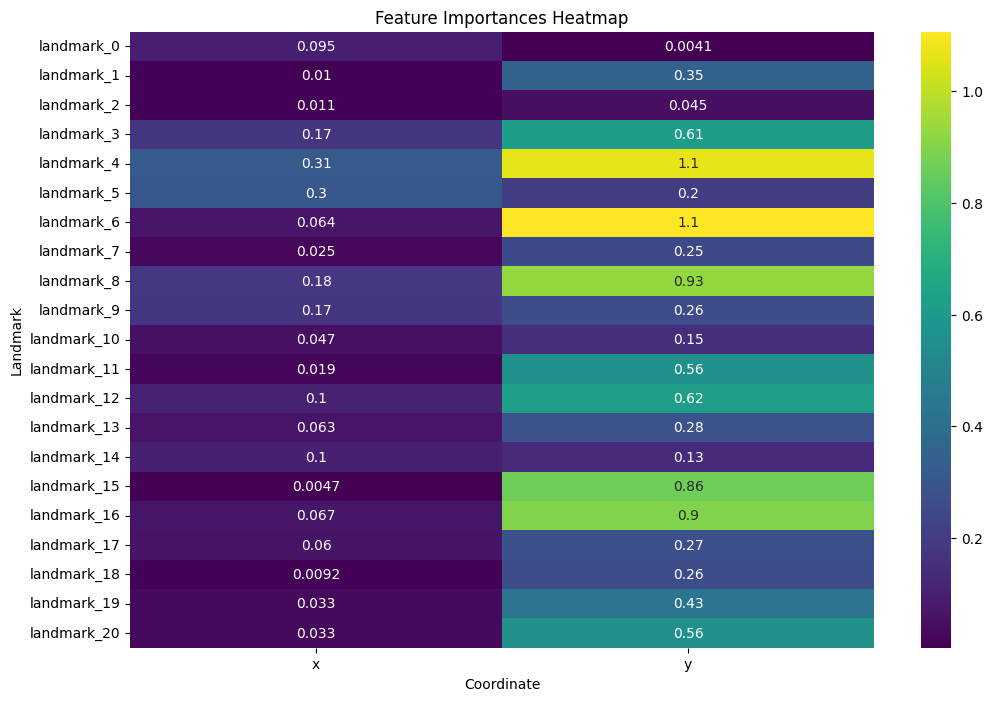

In [19]:
# Main function
if __name__ == "__main__":
    process_data()
    x_train, x_test, y_train, y_test = load_data()
    model = train_model(x_train, y_train)
    y_pred, mse = evaluate_model(model, x_test, y_test)
    visualize_feature_importances(model)

In [20]:
# Real-time prediction
def real_time_prediction():
    model_dict = pickle.load(open('model.p', 'rb'))
    model = model_dict['model']
    label_encoder = pickle.load(open('label_encoder.pickle', 'rb'))
    scaler = pickle.load(open('scaler.pickle', 'rb'))

    hands = mp_hands.Hands(static_image_mode=False, min_detection_confidence=0.3)
    cap = cv2.VideoCapture(0)

    while True:
        x_ = []
        y_ = []
        data_aux = []
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture frame from camera. Exiting...")
            break
        H, W, _ = frame.shape
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(frame_rgb)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    frame,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing_styles.get_default_hand_landmarks_style(),
                    mp_drawing_styles.get_default_hand_connections_style()
                )
                for i in range(len(hand_landmarks.landmark)):
                    x = hand_landmarks.landmark[i].x
                    y = hand_landmarks.landmark[i].y
                    data_aux.append(x)
                    data_aux.append(y)
                    x_.append(x)
                    y_.append(y)
            if len(data_aux) == 42:
                data_aux = scaler.transform([np.asarray(data_aux)])
                x1 = int(min(x_) * W) - 10
                y1 = int(min(y_) * H) - 10
                x2 = int(max(x_) * W) - 10
                y2 = int(max(y_) * H) - 10
                prediction = model.predict(data_aux)
                predicted_character = label_encoder.inverse_transform([int(prediction[0])])[0]
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 0), 4)
                cv2.putText(frame, predicted_character, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 0), 3, cv2.LINE_AA)

        cv2.imshow('frame', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
real_time_prediction()